# Конфиг

In [23]:
import os
import json
import random
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_auc_score, f1_score

In [24]:
# Фиксация seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [25]:
#  Проверка device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Пути

In [26]:
BASE_DATA = Path("/kaggle/input/datasets/taisiyaglazova/bcicompiii-ds2")
EPOCHS_DIR = BASE_DATA / "epochs"
SPLITS_DIR = BASE_DATA / "splits"
STATS_DIR  = BASE_DATA / "stats"

SSL_ENCODER_PATH = Path("/kaggle/input/datasets/taisiyaglazova/ssl-encoder-stage5/encoder_ssl_02.pt")

print("Epochs:", EPOCHS_DIR.exists())
print("Splits:", SPLITS_DIR.exists())
print("Stats :", STATS_DIR.exists())
print("Encoder:", SSL_ENCODER_PATH.exists())

Epochs: True
Splits: True
Stats : True
Encoder: True


## MODEL DEFINITION

In [27]:
import torch
import torch.nn as nn

class DoubleConv1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool1d(kernel_size=2, stride=2),
            DoubleConv1D(in_channels, out_channels)
        )

    def forward(self, x):
        return self.block(x)


class Up1D(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        self.bilinear = bilinear

        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="linear", align_corners=True)
            mid_channels = in_channels // 2
            self.conv = DoubleConv1D(in_channels, out_channels)
        else:
            self.up = nn.ConvTranspose1d(in_channels, out_channels, kernel_size=2, stride=2)
            self.conv = DoubleConv1D(in_channels, out_channels)

    def forward(self, x1, x2):
        # x1: низ, x2: skip
        x1 = self.up(x1)

        # подгоняем длину, если не совпадает
        diff = x2.size(-1) - x1.size(-1)
        if diff > 0:
            x1 = nn.functional.pad(x1, (diff // 2, diff - diff // 2))
        elif diff < 0:
            x2 = nn.functional.pad(x2, (-diff // 2, -diff - (-diff // 2)))

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class UNet1D_Light(nn.Module):
    """
    U-Net 1D с 4 уровнями даунсемплинга, вдохновлён Hong et al., 2025.
    Каналы: 32 → 64 → 128 → 256, bottleneck 512.
    """
    def __init__(self, n_channels, n_classes, base_ch=32, bilinear=True):
        super().__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        ch1 = base_ch
        ch2 = base_ch * 2
        ch3 = base_ch * 4
        ch4 = base_ch * 8
        bottleneck_ch = base_ch * 16  # 512 при base_ch=32

        # encoder
        self.inc = DoubleConv1D(n_channels, ch1)
        self.down1 = Down1D(ch1, ch2)
        self.down2 = Down1D(ch2, ch3)
        self.down3 = Down1D(ch3, ch4)
        self.down4 = Down1D(ch4, bottleneck_ch)

        # decoder
        self.up1 = Up1D(bottleneck_ch + ch4, ch4, bilinear)
        self.up2 = Up1D(ch4 + ch3, ch3, bilinear)
        self.up3 = Up1D(ch3 + ch2, ch2, bilinear)
        self.up4 = Up1D(ch2 + ch1, ch1, bilinear)
        self.outc = OutConv1D(ch1, n_classes)

    def encode(self, x):
        x1 = self.inc(x)     # (N, ch1, L)
        x2 = self.down1(x1)  # (N, ch2, L/2)
        x3 = self.down2(x2)  # (N, ch3, L/4)
        x4 = self.down3(x3)  # (N, ch4, L/8)
        x5 = self.down4(x4)  # (N, bottleneck_ch, L/16)
        return x1, x2, x3, x4, x5

    def decode(self, x1, x2, x3, x4, x5):
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

    def forward(self, x):
        x1, x2, x3, x4, x5 = self.encode(x)
        logits = self.decode(x1, x2, x3, x4, x5)
        return logits, x5  # x5 — bottleneck
    
class UNet1DEncoder(nn.Module):
    def __init__(self, inc, down1, down2, down3, down4):
        super().__init__()
        self.inc = inc
        self.down1 = down1
        self.down2 = down2
        self.down3 = down3
        self.down4 = down4

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        return x5
    
class ERPHead(nn.Module):
    """
    Минимальная классификационная голова для P300.
    Вход:  (B, F, T)
    Выход: (B, 2) logits
    """
    def __init__(self, in_features=512, num_classes=2):
        super().__init__()
        self.fc = nn.Linear(in_features, num_classes)

    def forward(self, z):
        # z: (B, F, T)
        z = z.mean(dim=-1)   # global average pooling → (B, F)
        logits = self.fc(z)  # (B, 2)
        return logits
    
class P300Model(nn.Module):
    """
    Полная downstream модель:
    x → encoder → head → logits
    """
    def __init__(self, encoder, head):
        super().__init__()
        self.encoder = encoder
        self.head = head

    def forward(self, x):
        z = self.encoder(x)
        logits = self.head(z)
        return logits

In [28]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

    return total_loss / len(loader.dataset)

In [29]:
class SimpleDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [30]:
def evaluate(model, loader, device):
    model.eval()
    
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            yb = yb.to(device)
            
            logits = model(Xb)
            probs = torch.softmax(logits, dim=1)[:, 1]  # вероятность target
            
            all_probs.append(probs.cpu().numpy())
            all_labels.append(yb.cpu().numpy())
    
    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    
    auc = roc_auc_score(all_labels, all_probs)
    
    preds = (all_probs > 0.5).astype(int)
    f1 = f1_score(all_labels, preds)
    
    return auc, f1

In [31]:
def build_model(init_type="ssl"):
    """
    init_type: "ssl" or "scratch"
    """
    unet = UNet1D_Light(n_channels=14, n_classes=14, base_ch=32)

    encoder = UNet1DEncoder(
        inc=unet.inc,
        down1=unet.down1,
        down2=unet.down2,
        down3=unet.down3,
        down4=unet.down4,
    )

    head = ERPHead(in_features=512, num_classes=2)
    model = P300Model(encoder, head).to(device)

    if init_type == "ssl":
        ssl_dict = torch.load(SSL_ENCODER_PATH, map_location=device)
        model.encoder.inc.load_state_dict(ssl_dict["inc"], strict=True)
        model.encoder.down1.load_state_dict(ssl_dict["down1"], strict=True)
        model.encoder.down2.load_state_dict(ssl_dict["down2"], strict=True)
        model.encoder.down3.load_state_dict(ssl_dict["down3"], strict=True)
        model.encoder.down4.load_state_dict(ssl_dict["down4"], strict=True)

    return model

In [32]:
def run_one(subject, p, init_type="ssl", epochs=30):

    set_seed(42)
    
    # ===== 1. Load data =====
    epoch_path = EPOCHS_DIR / f"{subject}_train_epochs_v1.npz"
    data = np.load(epoch_path)
    X = data["X"]
    y = data["y"]
    L_raw = 205

    split_path = SPLITS_DIR / f"{subject}_time30_seed42_v1.json"
    with open(split_path, "r") as f:
        split = json.load(f)

    indices = split["indices"]
    calib_idx = indices["calib_idx"][str(p)]
    test_idx = indices["test_rest_idx"]

    X_calib = X[calib_idx]
    y_calib = y[calib_idx]
    X_test = X[test_idx]
    y_test = y[test_idx]

    # ===== 2. Normalization =====
    stats_path = STATS_DIR / f"{subject}_time30_seed42_p{p}_v1.npz"
    stats = np.load(stats_path)
    mean = stats["mean"]
    std = stats["std"]

    def normalize(X):
        Xn = X.copy()
        Xn[:, :, :L_raw] = (
            Xn[:, :, :L_raw] - mean[None, :, None]
        ) / std[None, :, None]
        return Xn

    X_calib = normalize(X_calib)
    X_test = normalize(X_test)

    # ===== 3. Torch tensors =====
    X_calib = torch.tensor(X_calib, dtype=torch.float32)
    y_calib = torch.tensor(y_calib, dtype=torch.long)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.long)

    train_loader = DataLoader(
        SimpleDataset(X_calib, y_calib),
        batch_size=64,
        shuffle=True
    )

    test_loader = DataLoader(
        SimpleDataset(X_test, y_test),
        batch_size=256,
        shuffle=False
    )

    # ==== Class weights ====
    class_counts = np.bincount(y_calib)
    weights = 1.0 / class_counts
    weights = weights / weights.sum() * 2
    weights = torch.tensor(weights, dtype=torch.float32).to(device)

    criterion = torch.nn.CrossEntropyLoss(weight=weights)

    # ==== Build model ====
    model = build_model(init_type).to(device)

    best_auc = 0.0

    # =====================================================
    # =============== SCRATCH REGIME ======================
    # =====================================================
    if init_type == "scratch":

        optimizer = torch.optim.AdamW([
            {"params": model.encoder.parameters(), "lr": 1e-5},
            {"params": model.head.parameters(), "lr": 1e-4}
        ], weight_decay=1e-4)

        for epoch in range(epochs):
            train_one_epoch(model, train_loader, optimizer, criterion, device)
            auc, _ = evaluate(model, test_loader, device)

            if auc > best_auc:
                best_auc = auc

    # =====================================================
    # =============== SSL WARMUP REGIME ===================
    # =====================================================
    elif init_type == "ssl":

        warmup_epochs = 5
        total_epochs = epochs

        # ---- Phase 1: freeze encoder ----
        for param in model.encoder.parameters():
            param.requires_grad = False

        optimizer = torch.optim.AdamW(
            model.head.parameters(),
            lr=1e-4,
            weight_decay=1e-4
        )

        for epoch in range(warmup_epochs):
            train_one_epoch(model, train_loader, optimizer, criterion, device)
            auc, _ = evaluate(model, test_loader, device)

            if auc > best_auc:
                best_auc = auc

        # ---- Phase 2: unfreeze encoder ----
        for param in model.encoder.parameters():
            param.requires_grad = True

        optimizer = torch.optim.AdamW([
            {"params": model.encoder.parameters(), "lr": 1e-5},
            {"params": model.head.parameters(), "lr": 1e-4}
        ], weight_decay=1e-4)

        for epoch in range(warmup_epochs, total_epochs):
            train_one_epoch(model, train_loader, optimizer, criterion, device)
            auc, _ = evaluate(model, test_loader, device)

            if auc > best_auc:
                best_auc = auc

    return best_auc

In [33]:
subjects = ["subjA", "subjB"]
p_list = [10, 20, 40, 60, 100]

results = []

for subject in subjects:
    print(f"\n===== Running subject: {subject} =====")
    
    for p in p_list:
        auc_scratch = run_one(subject, p, init_type="scratch", epochs=30)
        auc_ssl = run_one(subject, p, init_type="ssl", epochs=30)

        print(f"{subject} | p={p} | Scratch AUC={auc_scratch:.4f} | SSL AUC={auc_ssl:.4f}")

        results.append({
            "subject": subject,
            "p": p,
            "scratch_auc": auc_scratch,
            "ssl_auc": auc_ssl
        })

results_df = pd.DataFrame(results)
results_df


===== Running subject: subjA =====
subjA | p=10 | Scratch AUC=0.5279 | SSL AUC=0.5335
subjA | p=20 | Scratch AUC=0.5331 | SSL AUC=0.5385
subjA | p=40 | Scratch AUC=0.5358 | SSL AUC=0.5425
subjA | p=60 | Scratch AUC=0.5413 | SSL AUC=0.5519
subjA | p=100 | Scratch AUC=0.5512 | SSL AUC=0.5719

===== Running subject: subjB =====
subjB | p=10 | Scratch AUC=0.5411 | SSL AUC=0.5231
subjB | p=20 | Scratch AUC=0.5387 | SSL AUC=0.5339
subjB | p=40 | Scratch AUC=0.5442 | SSL AUC=0.5577
subjB | p=60 | Scratch AUC=0.5559 | SSL AUC=0.5743
subjB | p=100 | Scratch AUC=0.5638 | SSL AUC=0.6544


,subject,p,scratch_auc,ssl_auc
0,subjA,10,0.527864,0.533475
1,subjA,20,0.533105,0.538476
2,subjA,40,0.535828,0.542501
3,subjA,60,0.541305,0.551901
4,subjA,100,0.551187,0.571874
5,subjB,10,0.541065,0.523075
6,subjB,20,0.538711,0.533922
7,subjB,40,0.544234,0.557729
8,subjB,60,0.555935,0.574323
9,subjB,100,0.563816,0.654352


In [34]:
results_df.to_csv(
    "/kaggle/working/stage5_ft_low_lr_encoder_v1_results.csv",
    index=False
)

In [35]:
pivot_df = results_df.pivot(index="p", columns="subject")
pivot_df

scratch_auc             ssl_auc          
subject       subjA     subjB     subjA     subjB
p                                                
10         0.527864  0.541065  0.533475  0.523075
20         0.533105  0.538711  0.538476  0.533922
40         0.535828  0.544234  0.542501  0.557729
60         0.541305  0.555935  0.551901  0.574323
100        0.551187  0.563816  0.571874  0.654352

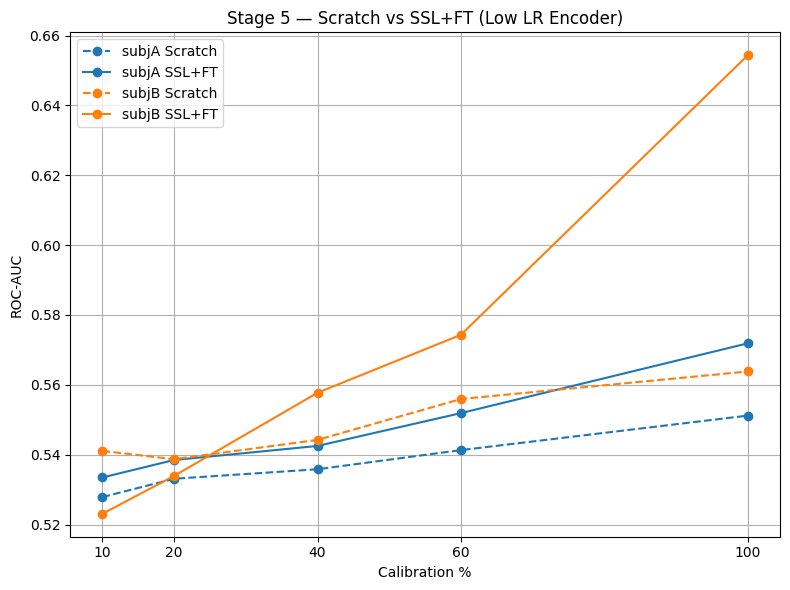

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Цвета для субъектов
colors = {
    "subjA": "tab:blue",
    "subjB": "tab:orange"
}

for subject in results_df["subject"].unique():
    df_sub = results_df[results_df["subject"] == subject]
    color = colors[subject]
    
    # Scratch — пунктир
    plt.plot(df_sub["p"], df_sub["scratch_auc"],
             marker="o",
             linestyle="--",
             color=color,
             label=f"{subject} Scratch")
    
    # SSL — сплошная
    plt.plot(df_sub["p"], df_sub["ssl_auc"],
             marker="o",
             linestyle="-",
             color=color,
             label=f"{subject} SSL+FT")

plt.xlabel("Calibration %")
plt.ylabel("ROC-AUC")
plt.title("Stage 5 — Scratch vs SSL+FT (Low LR Encoder)")
plt.xticks([10,20,40,60,100])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("/kaggle/working/ft_head_warmup_low_lr_v1_all_subjects.png", dpi=300)
plt.show()

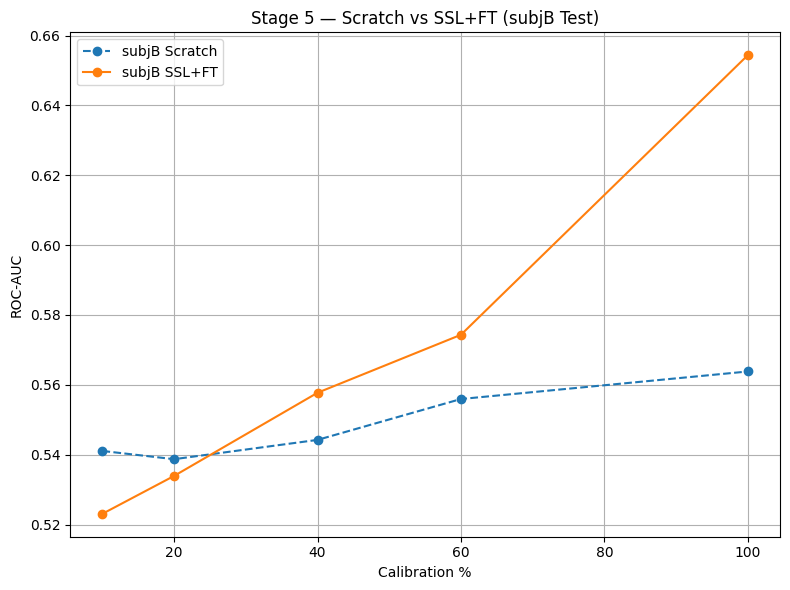

In [48]:
plt.figure(figsize=(8,6))

df_B = results_df[results_df["subject"] == "subjB"]

plt.plot(df_B["p"], df_B["scratch_auc"],
         marker="o", linestyle="--",
         label="subjB Scratch")

plt.plot(df_B["p"], df_B["ssl_auc"],
         marker="o", linestyle="-",
         label="subjB SSL+FT")

plt.xlabel("Calibration %")
plt.ylabel("ROC-AUC")
plt.title("Stage 5 — Scratch vs SSL+FT (subjB Test)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("/kaggle/working/ft_head_warmup_low_lr_subjB.png", dpi=300)
plt.show()

In [39]:
plt.savefig("/kaggle/working/stage5_ft_low_lr_encoder_v1_subjB.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [40]:
results_df["delta_auc"] = results_df["ssl_auc"] - results_df["scratch_auc"]

results_df

,subject,p,scratch_auc,ssl_auc,delta_auc
0,subjA,10,0.527864,0.533475,0.005611
1,subjA,20,0.533105,0.538476,0.005371
2,subjA,40,0.535828,0.542501,0.006672
3,subjA,60,0.541305,0.551901,0.010596
4,subjA,100,0.551187,0.571874,0.020687
5,subjB,10,0.541065,0.523075,-0.017990
6,subjB,20,0.538711,0.533922,-0.004790
7,subjB,40,0.544234,0.557729,0.013495
8,subjB,60,0.555935,0.574323,0.018389
9,subjB,100,0.563816,0.654352,0.090535


In [41]:
delta_pivot = results_df.pivot(index="p", columns="subject", values="delta_auc")
delta_pivot

subject,subjA,subjB
p,,
10,0.005611,-0.017990
20,0.005371,-0.004790
40,0.006672,0.013495
60,0.010596,0.018389
100,0.020687,0.090535


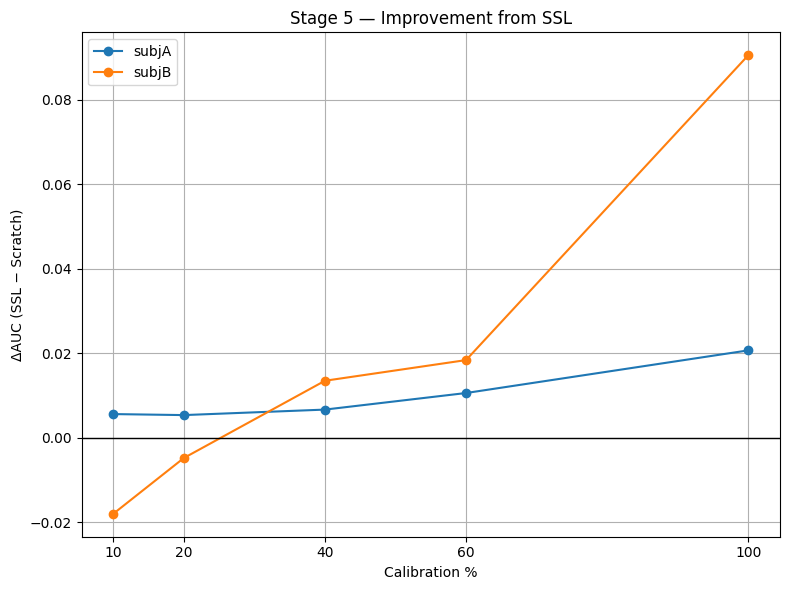

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

colors = {
    "subjA": "tab:blue",
    "subjB": "tab:orange"
}

for subject in results_df["subject"].unique():
    df_sub = results_df[results_df["subject"] == subject]
    
    plt.plot(df_sub["p"], df_sub["delta_auc"],
             marker="o",
             linestyle="-",
             color=colors[subject],
             label=subject)

plt.axhline(0, color="black", linewidth=1)  # линия нуля
plt.xlabel("Calibration %")
plt.ylabel("ΔAUC (SSL − Scratch)")
plt.title("Stage 5 — Improvement from SSL")
plt.xticks([10,20,40,60,100])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("/kaggle/working/ft_head_warmup_low_lr_delta_auc_all_subjects.png", dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>

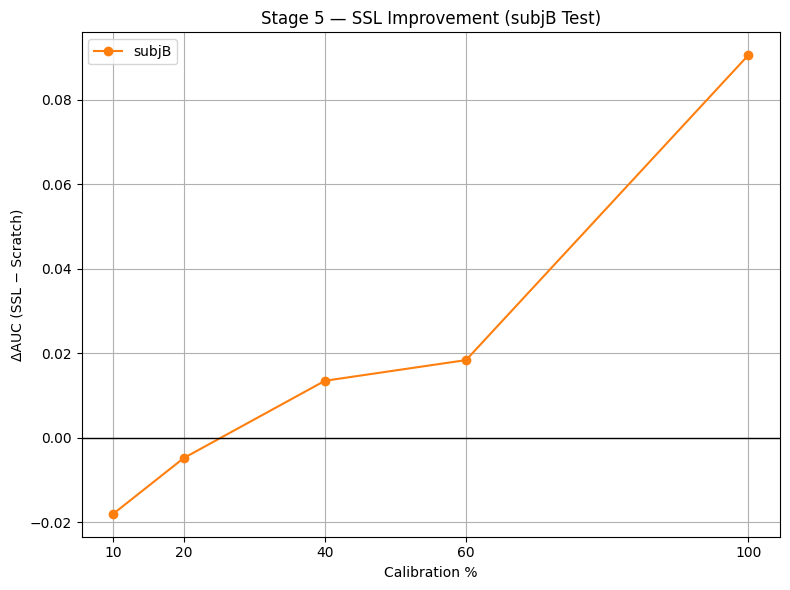

In [50]:
plt.figure(figsize=(8,6))

df_B = results_df[results_df["subject"] == "subjB"]

plt.plot(df_B["p"], df_B["delta_auc"],
         marker="o",
         linestyle="-",
         color="tab:orange",
         label="subjB")

plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Calibration %")
plt.ylabel("ΔAUC (SSL − Scratch)")
plt.title("Stage 5 — SSL Improvement (subjB Test)")
plt.xticks([10,20,40,60,100])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("/kaggle/working/ft_head_warmup_low_lr_delta_auc_subjB.png", dpi=300)
plt.show()

In [49]:
plt.savefig("/kaggle/working/ft_head_warmup_low_lr_delta_auc_subjB.png", dpi=300)

<Figure size 640x480 with 0 Axes>